## K-Median Clustering Implementation

/tmp/ipykernel_373/2774560910.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


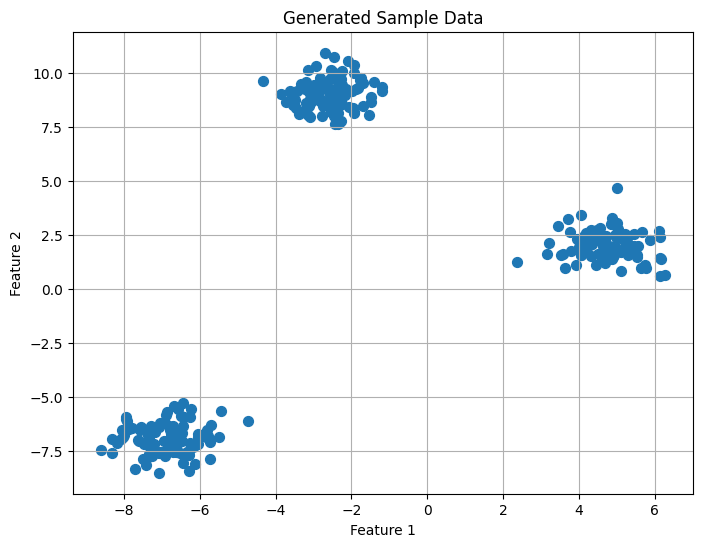

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


n_samples = 300
n_features = 2
n_centers = 3
random_state = 42

X, y_true = make_blobs(n_samples=n_samples, centers=n_centers, cluster_std=0.70, random_state=random_state)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title('Generated Sample Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()


In [7]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

def manhattan_distance(point1, point2):
    return np.sum(np.abs(point1 - point2))

def k_median_clustering(X, k, max_iterations=100):
    n_samples, n_features = X.shape

    initial_median_indices = np.random.choice(n_samples, k, replace=False)
    medians = X[initial_median_indices]

    for iteration in range(max_iterations):
        clusters = [[] for _ in range(k)]
        for i, sample in enumerate(X):
            distances = [manhattan_distance(sample, median) for median in medians]
            cluster_idx = np.argmin(distances)
            clusters[cluster_idx].append(i)

        new_medians = np.zeros_like(medians)
        for j in range(k):
            if len(clusters[j]) > 0:
                cluster_points = X[clusters[j]]
                for feature_idx in range(n_features):
                    new_medians[j, feature_idx] = np.median(cluster_points[:, feature_idx])
            else:
                new_medians[j] = X[np.random.choice(n_samples, 1, replace=False)]

        if np.allclose(medians, new_medians):
            break
        medians = new_medians


    final_labels = np.zeros(n_samples)
    for i, sample in enumerate(X):
        distances = [manhattan_distance(sample, median) for median in medians]
        final_labels[i] = np.argmin(distances)

    return final_labels, medians


k_median_labels, k_median_medians = k_median_clustering(X, k=n_centers)

print('K-Median Medians:')
print(k_median_medians)


K-Median Medians:
[[-2.53388586  9.12806881]
 [-6.8275001  -7.01779402]
 [ 4.70035902  1.9811586 ]]


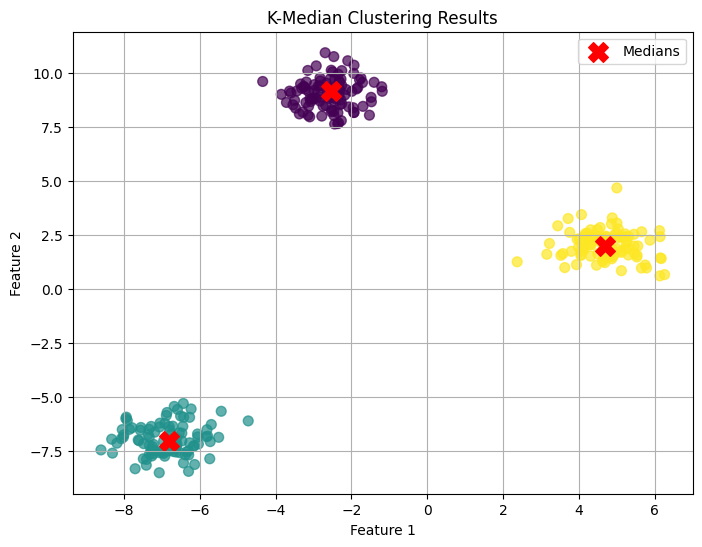

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=k_median_labels, s=50, cmap='viridis', alpha=0.7)
plt.scatter(k_median_medians[:, 0], k_median_medians[:, 1], c='red', marker='X', s=200, label='Medians')
plt.title('K-Median Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()